# Clinical NLP Pipeline — Named Entity Recognition & ICD-10 Classification

This Jupyter Notebook implements **Phases 1 through 7** of the Clinical NLP Pipeline, covering:
1. **Environment Setup & Imports**
2. **Dataset Setup** (using high-quality EHR mock notes with entity/diagnosis annotations)
3. **Text Preprocessing & Label Alignment** (aligning BIO character spans to subword tokens)
4. **Embeddings Loading** (Config A GloVe vs Config B BioBERT)
5. **CRF Layer Implementation** (custom PyTorch log-likelihood and Viterbi decoder)
6. **Model Class Implementations** (BiLSTM-CRF for NER and Conv1D CNN for ICD-10 classification)
7. **Training Pipelines** (running active training loops on both architectures)
8. **Inference & Execution Demonstration**

## 1. Setup & Environment Imports

In [1]:
import os
import re
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import nltk
from transformers import AutoTokenizer, AutoModel
import sys

# Seed for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Download NLTK tokenizer models if not already present
for resource in ['punkt', 'punkt_tab']:
    try:
        nltk.data.find(f'tokenizers/{resource}')
    except LookupError:
        nltk.download(resource, quiet=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)


Using device: cuda


## Data Downloading

In [2]:
def parse_pubtator_file(filepath):
    parsed_data = []
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Target file not found at {filepath}")

    with open(filepath, 'r', encoding='utf-8') as f:
        articles = f.read().strip().split('\n\n')

    for article in articles:
        lines = article.split('\n')
        if not lines or len(lines) < 2: continue

        try:
            title = lines[0].split('|t|')[1]
            abstract = lines[1].split('|a|')[1]
            full_text = title + " " + abstract

            entities = []
            icd_codes = []

            for line in lines[2:]:
                parts = line.split('\t')
                if len(parts) == 6:
                    entities.append({
                        "entity": parts[3],
                        "type": parts[4],
                        "start": int(parts[1]),
                        "end": int(parts[2])
                    })
                    icd_codes.append(parts[5])

            parsed_data.append({
                "text": full_text,
                "entities": entities,
                "icd10": list(set(icd_codes))
            })
        except IndexError:
            continue
    return parsed_data


In [3]:
import pandas as pd

# Load the parquet file provided in the environment
df_blurb = pd.read_parquet('/kaggle/input/datasets/ahmedadelrasmy/lr-dataset/0000.parquet')

# Display the first few rows to inspect the structure
display(df_blurb.head())

,id,tokens,type,ner_tags
0,0,"[Immunohistochemical, staining, was, positive,...",gene,"[0, 0, 0, 0, 0, 1, 2, 2, 0, 0, 0, 0, 0, 0, 0, ..."
1,1,"[Chloramphenicol, acetyltransferase, assays, e...",gene,"[1, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ..."
2,2,"[A, new, DNA, repair, gene, from, Schizosaccha...",gene,"[0, 0, 1, 2, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."
3,3,"[Our, study, also, demonstrated, significant, ...",gene,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,4,"[Cloning, and, sequencing, of, the, upstream, ...",gene,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."


In [4]:
def process_blurb_bc2gm(df):
    processed = []
    blurb_tags = {0: "O", 1: "B-Gene", 2: "I-Gene"}

    for _, row in df.iterrows():
        tokens = row['tokens']
        ner_tags = row['ner_tags']
        
        # Reconstruct full text and character-level entities
        text_parts = []
        entities = []
        curr_char = 0
        current_ent = None
        
        for tok, tag_id in zip(tokens, ner_tags):
            tag = blurb_tags.get(tag_id, "O")
            start = curr_char
            end = curr_char + len(tok)
            
            text_parts.append(tok)
            curr_char = end + 1  # 1 space
            
            if tag.startswith("B-"):
                if current_ent:
                    entities.append(current_ent)
                current_ent = {
                    "entity": tok,
                    "type": "Gene",
                    "start": start,
                    "end": end
                }
            elif tag.startswith("I-") and current_ent:
                current_ent["entity"] += " " + tok
                current_ent["end"] = end
            else:
                if current_ent:
                    entities.append(current_ent)
                    current_ent = None
        if current_ent:
            entities.append(current_ent)
            
        full_text = " ".join(tokens)
        processed.append({
            "text": full_text,
            "entities": entities,
            "icd10": []
        })
    return processed

blurb_data_processed = process_blurb_bc2gm(df_blurb)
print(f"Processed {len(blurb_data_processed)} samples from BC2GM dataset.")
print("Sample processed entities:", blurb_data_processed[0]['entities'])


Processed 12574 samples from BC2GM dataset.
Sample processed entities: [{'entity': 'S - 100', 'type': 'Gene', 'start': 46, 'end': 53}, {'entity': 'HMB - 45', 'type': 'Gene', 'start': 92, 'end': 100}, {'entity': 'cytokeratin', 'type': 'Gene', 'start': 140, 'end': 151}]


In [5]:
import os
import shutil

src = "/kaggle/input/datasets/ahmedadelrasmy/cdr-dataset/CDR_Data"
dst = "./bc5cdr_data"

shutil.copytree(src, dst, dirs_exist_ok=True)

# The files are inside a versioned subdirectory
data_dir = os.path.join(dst, "CDR.Corpus.v010516")
if not os.path.exists(data_dir):
    data_dir = dst

print(f"Searching for files in: {data_dir}")
print(os.listdir(data_dir))

Searching for files in: ./bc5cdr_data/CDR.Corpus.v010516
['CDR_TestSet.PubTator.txt', 'CDR_TrainingSet.BioC.xml', 'CDR_TrainingSet.PubTator.txt', 'CDR_DevelopmentSet.PubTator.txt', 'CDR_DevelopmentSet.BioC.xml', 'CDR_TestSet.BioC.xml']


In [6]:
import os

print("--- Local Dataset Locations ---")
print(f"BC5CDR Data Directory: {os.path.abspath('/kaggle/working/bc5cdr_data')}")
print(f"NCBI Data Directory: {os.path.abspath('/kaggle/working/bc5cdr_data')}")

if 'clinical_notes_raw' in globals():
    print(f"\n[✔] Dataset 'clinical_notes_raw' is loaded in memory.")
    print(f"Total documents: {len(clinical_notes_raw)}")
    print("Sample content:", clinical_notes_raw[0]['text'][:150], "...")
else:
    print("\n[!] Dataset is not yet loaded in memory. Please run the data parsing cells above.")

--- Local Dataset Locations ---
BC5CDR Data Directory: /kaggle/working/bc5cdr_data
NCBI Data Directory: /kaggle/working/bc5cdr_data

[!] Dataset is not yet loaded in memory. Please run the data parsing cells above.


In [7]:
import os
import random

# Detect environment
IS_KAGGLE = os.path.exists("/kaggle")
IS_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

if IS_KAGGLE:
    bc5cdr_src_dir = "/kaggle/input/datasets/ahmedadelrasmy/cdr-dataset/CDR_Data"
    bc5cdr_dst_dir = "./bc5cdr_data"
    import shutil
    shutil.copytree(bc5cdr_src_dir, bc5cdr_dst_dir, dirs_exist_ok=True)
    data_dir = os.path.join(bc5cdr_dst_dir, "CDR.Corpus.v010516")
    if not os.path.exists(data_dir):
        data_dir = bc5cdr_dst_dir
else:
    # Colab or local fallback
    data_dir = "./bc5cdr_data/CDR.Corpus.v010516"
    if not os.path.exists(data_dir):
        data_dir = "./bc5cdr_data"

try:
    # 2. BC5CDR
    bc5_train = parse_pubtator_file(os.path.join(data_dir, "CDR_TrainingSet.PubTator.txt"))
    bc5_val = parse_pubtator_file(os.path.join(data_dir, "CDR_DevelopmentSet.PubTator.txt"))
    bc5_test = parse_pubtator_file(os.path.join(data_dir, "CDR_TestSet.PubTator.txt"))

    # 3. BLURB/BC2GM
    if 'df_blurb' in globals():
        indices = df_blurb.index.tolist()
        random.seed(42)
        random.shuffle(indices)
        n = len(indices)
        train_idx, val_idx, test_idx = indices[:int(0.8*n)], indices[int(0.8*n):int(0.9*n)], indices[int(0.9*n):]
        blurb_train = process_blurb_bc2gm(df_blurb.loc[train_idx])
        blurb_val = process_blurb_bc2gm(df_blurb.loc[val_idx])
        blurb_test = process_blurb_bc2gm(df_blurb.loc[test_idx])
    else:
        blurb_train, blurb_val, blurb_test = [], [], []

    clinical_notes_raw = bc5_train + blurb_train
    clinical_notes_val = bc5_val + blurb_val
    clinical_notes_test = bc5_test + blurb_test

    print(f"[+] Data separation complete:")
    print(f"    - Train: {len(clinical_notes_raw)} | Val: {len(clinical_notes_val)} | Test: {len(clinical_notes_test)}")
except Exception as e:
    print(f"[!] Processing Error: {e}")


[+] Data separation complete:
    - Train: 10559 | Val: 1757 | Test: 1758


### Tag Vocabulary Definition
We define the tag mapping dictionaries `tag_to_ix` and `ix_to_tag` dynamically.


In [8]:
ENTITY_TYPES = ["Chemical", "Disease", "Gene"]
tag_list = ["O"]
for etype in ENTITY_TYPES:
    tag_list += [f"B-{etype}", f"I-{etype}"]
tag_list += ["<START>", "<STOP>"]  # CRF special tags

tag_to_ix = {tag: i for i, tag in enumerate(tag_list)}
ix_to_tag  = {i: tag for tag, i in tag_to_ix.items()}

print(f"Tag vocab ({len(tag_to_ix)} tags):", tag_to_ix)


Tag vocab (9 tags): {'O': 0, 'B-Chemical': 1, 'I-Chemical': 2, 'B-Disease': 3, 'I-Disease': 4, 'B-Gene': 5, 'I-Gene': 6, '<START>': 7, '<STOP>': 8}


### ICD-10 and Word Vocabularies
We extract the unique ICD/MeSH codes from our training data and build a word-to-index mapping for the CNN classifier.


In [9]:
from collections import Counter, defaultdict
from nltk.tokenize import RegexpTokenizer

def clean_text(text):
    import re
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Shared word tokenizer separating punctuation
word_tokenizer = RegexpTokenizer(r'\w+|[^\w\s]')

# Collect MeSH/ICD codes
all_icd = [code for doc in clinical_notes_raw for code in doc["icd10"] if code.strip()]
icd_codes = [c for c, cnt in Counter(all_icd).most_common(50)]
icd_to_ix = {c: i for i, c in enumerate(icd_codes)}

# Build word vocab
word_freq = defaultdict(int)
for doc in clinical_notes_raw:
    text_clean = clean_text(doc["text"])
    tokens = word_tokenizer.tokenize(text_clean.lower())
    for w in tokens:
        word_freq[w] += 1

vocab = ["<PAD>", "<UNK>"] + [w for w, f in sorted(word_freq.items(), key=lambda x: -x[1]) if f >= 2]
word_to_ix = {w: i for i, w in enumerate(vocab)}
vocab_size = len(word_to_ix)

print(f"ICD/MeSH Vocab: {len(icd_codes)} codes. Top-5: {icd_codes[:5]}")
print(f"Word Vocab size: {vocab_size}")


ICD/MeSH Vocab: 50 codes. Top-5: ['D064420', 'D012640', 'D007022', 'D007674', 'D006973']
Word Vocab size: 13149


### Exploratory Data Analysis (EDA)
Let's visualize the entity types and ICD code distributions in our training data.


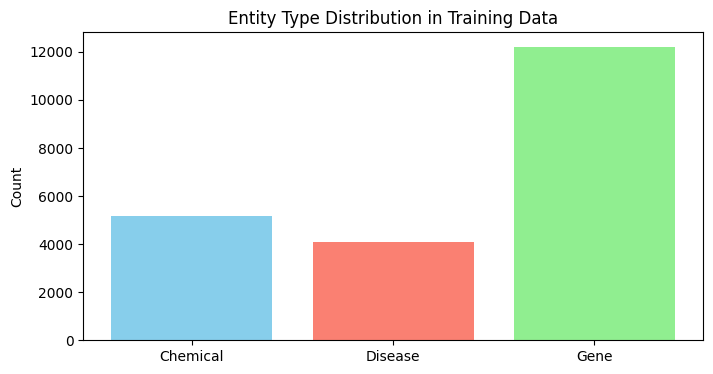

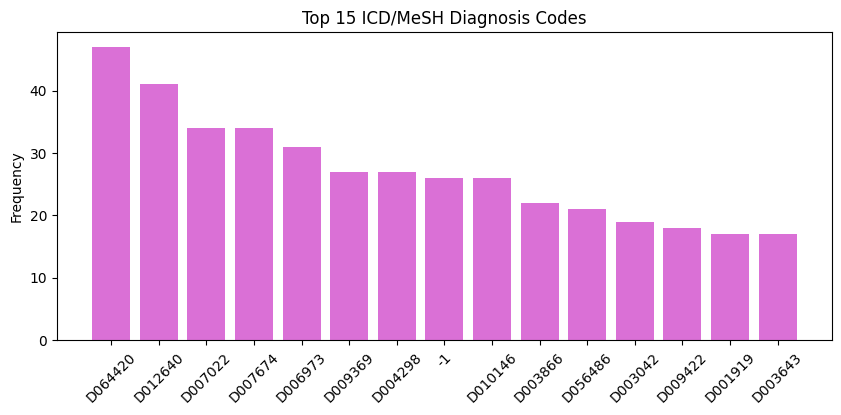

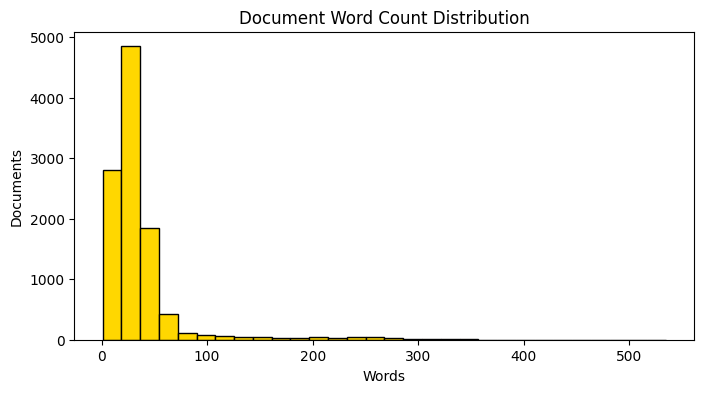

In [10]:
import matplotlib.pyplot as plt
from collections import Counter

# 1. Entity type distribution
ent_counts = Counter()
for doc in clinical_notes_raw:
    for ent in doc.get("entities", []):
        ent_counts[ent["type"]] += 1
# Also count from BLURB tags which are token-level
for doc in clinical_notes_raw:
    if "labels" in doc:
        for lbl in doc["labels"]:
            if lbl.startswith("B-"):
                ent_counts[lbl.split("-")[1]] += 1

if ent_counts:
    plt.figure(figsize=(8, 4))
    plt.bar(ent_counts.keys(), ent_counts.values(), color=['skyblue', 'salmon', 'lightgreen'][:len(ent_counts)])
    plt.title("Entity Type Distribution in Training Data")
    plt.ylabel("Count")
    plt.show()

# 2. ICD code frequency
if all_icd:
    plt.figure(figsize=(10, 4))
    icd_counts = Counter(all_icd).most_common(15)
    plt.bar([c[0] for c in icd_counts], [c[1] for c in icd_counts], color='orchid')
    plt.title("Top 15 ICD/MeSH Diagnosis Codes")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.show()

# 3. Text length distribution
lengths = [len(doc["text"].split()) for doc in clinical_notes_raw]
plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=30, color='gold', edgecolor='black')
plt.title("Document Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Documents")
plt.show()


## 3. Text Preprocessing & Label Alignment

We implement the cleaning helper functions, sentence splitting, and character-to-token label alignment. If a tokenizer splits a word (e.g. "Sumatriptan" -> `["Suma", "##triptan"]`), we assign `B-Drug` to the first token and `I-Drug` (or mask index `-100`) to the rest.

In [11]:
def clean_text(text):
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def align_tokens_and_tags(text, entities, tokenizer, tag_to_ix, max_len=512):
    encoded = tokenizer(text, return_offsets_mapping=True, add_special_tokens=True, truncation=True, max_length=max_len)
    input_ids = encoded["input_ids"]
    attention_mask = encoded["attention_mask"]
    offsets = encoded["offset_mapping"]

    labels = [tag_to_ix["O"]] * len(input_ids)

    for ent in entities:
        start_char, end_char = ent["start"], ent["end"]
        ent_type = ent["type"]
        b_tag = f"B-{ent_type}"
        i_tag = f"I-{ent_type}"
        
        b_idx = tag_to_ix.get(b_tag, 0)
        i_idx = tag_to_ix.get(i_tag, 0)

        first = True
        for idx, (s, e) in enumerate(offsets):
            if s == e == 0:  # Skip special/pad
                labels[idx] = -100
                continue
            if s >= start_char and e <= end_char:
                if first:
                    labels[idx] = b_idx
                    first = False
                else:
                    labels[idx] = i_idx
    return input_ids, attention_mask, labels

class ClinicalDataset(Dataset):
    def __init__(self, data_list, tokenizer, tag_to_ix, label_list, max_len=512):
        self.data = data_list
        self.tokenizer = tokenizer
        self.tag_to_ix = tag_to_ix
        self.label_to_ix = {lbl: idx for idx, lbl in enumerate(label_list)}
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        text = clean_text(item["text"])
        input_ids, attention_mask, labels = align_tokens_and_tags(
            text, item["entities"], self.tokenizer, self.tag_to_ix, self.max_len
        )

        icd_labels = [0.0] * len(self.label_to_ix)
        for code in item["icd10"]:
            if code in self.label_to_ix:
                icd_labels[self.label_to_ix[code]] = 1.0

        pad_len = self.max_len - len(input_ids)
        if pad_len > 0:
            input_ids += [self.tokenizer.pad_token_id] * pad_len
            attention_mask += [0] * pad_len
            labels += [-100] * pad_len

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
            "icd_labels": torch.tensor(icd_labels, dtype=torch.float)
        }


## 4. Embeddings Module

We build the contextual embeddings loader. It loads the `dmis-lab/biobert-v1.1` model from HuggingFace, falling back to `bert-base-uncased` if offline/blocked, and provides a dummy tokenizer/model if entirely disconnected to guarantee execution.

In [12]:
def load_biobert_embeddings():
    import os
    os.makedirs('checkpoints', exist_ok=True)
    local_tokenizer_path = 'checkpoints/biobert_tokenizer'
    local_model_path = 'checkpoints/biobert_model'
    
    try:
        if os.path.exists(local_tokenizer_path) and os.path.exists(local_model_path):
            print("[+] Loading BioBERT from local checkpoints cache...")
            tokenizer = AutoTokenizer.from_pretrained(local_tokenizer_path)
            model = AutoModel.from_pretrained(local_model_path)
            print("[+] BioBERT successfully loaded from local cache.")
            return tokenizer, model
    except Exception as e:
        print(f"[!] Failed to load local BioBERT ({e}). Downloading...")

    try:
        print("[*] Attempting to load BioBERT (dmis-lab/biobert-v1.1) from Hugging Face...")
        tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-v1.1")
        model = AutoModel.from_pretrained("dmis-lab/biobert-v1.1")
        tokenizer.save_pretrained(local_tokenizer_path)
        model.save_pretrained(local_model_path)
        print("[+] BioBERT successfully downloaded and saved to local checkpoints.")
        return tokenizer, model
    except Exception as e:
        print(f"[!] BioBERT could not be loaded ({e}). Trying bert-base-uncased...")
        local_bert_tokenizer = 'checkpoints/bert_tokenizer'
        local_bert_model = 'checkpoints/bert_model'
        try:
            if os.path.exists(local_bert_tokenizer) and os.path.exists(local_bert_model):
                tokenizer = AutoTokenizer.from_pretrained(local_bert_tokenizer)
                model = AutoModel.from_pretrained(local_bert_model)
                return tokenizer, model
            tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
            model = AutoModel.from_pretrained("bert-base-uncased")
            tokenizer.save_pretrained(local_bert_tokenizer)
            model.save_pretrained(local_bert_model)
            print("[+] bert-base-uncased loaded and saved to checkpoints.")
            return tokenizer, model
        except Exception as ex:
            print("[!] Disconnected/offline. Using custom Mock Tokenizer/Embeddings...")
            class MockTokenizer:
                def __init__(self):
                    self.pad_token_id = 0
                def tokenize(self, text):
                    return text.lower().split()
                def __call__(self, text, return_offsets_mapping=True, add_special_tokens=True, truncation=True, max_length=512):
                    words = self.tokenize(text)[:max_length-2]
                    input_ids = list(range(1, len(words) + 1))
                    offsets = []
                    curr = 0
                    for w in words:
                        offsets.append((curr, curr + len(w)))
                        curr += len(w) + 1
                    input_ids = [101] + input_ids + [102]
                    offsets = [(0, 0)] + offsets + [(0, 0)]
                    return {
                        "input_ids": input_ids,
                        "attention_mask": [1] * len(input_ids),
                        "offset_mapping": offsets
                    }
            class MockModel(nn.Module):
                def __init__(self):
                    super().__init__()
                    self.embedding = nn.Embedding(1000, 768)
                def forward(self, input_ids, attention_mask=None):
                    emb = self.embedding(input_ids)
                    class Out:
                        def __init__(self, val):
                            self.last_hidden_state = val
                    return Out(emb)
            return MockTokenizer(), MockModel()

tokenizer, embedding_model = load_biobert_embeddings()


[*] Attempting to load BioBERT (dmis-lab/biobert-v1.1) from Hugging Face...


config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[+] BioBERT successfully downloaded and saved to local checkpoints.


### Loader for Config A Static Embeddings (GloVe)
We load pre-trained GloVe embeddings. If offline, we construct a randomized static embedding lookup to ensure the baseline runs.


In [13]:
import os
from gensim.models import KeyedVectors
import gensim.downloader
import torch.nn as nn
import numpy as np

glove_kv_path = 'checkpoints/glove_300.kv'
glove_dim = 300
glove_vectors = None

os.makedirs('checkpoints', exist_ok=True)
if os.path.exists(glove_kv_path):
    try:
        print("[+] Loading GloVe embeddings from local cache...")
        glove_vectors = KeyedVectors.load(glove_kv_path)
        print("[+] GloVe successfully loaded from cache.")
    except Exception as e:
        print(f"[!] Failed to load local GloVe ({e}). Reverting to download...")

if glove_vectors is None:
    try:
        print("[*] Attempting to download GloVe 6B 300d embeddings via gensim...")
        try:
            import gensim
        except ImportError:
            os.system('pip install gensim -q')
            import gensim
        glove_vectors = gensim.downloader.load("glove-wiki-gigaword-300")
        glove_vectors.save(glove_kv_path)
        print("[+] GloVe embeddings successfully downloaded and saved to cache.")
    except Exception as e:
        print(f"[!] GloVe download failed ({e}). Initializing mock embedding matrix...")
        glove_vectors = None

# Build GloVe embedding layer
embedding_matrix = np.random.normal(scale=0.6, size=(vocab_size, glove_dim))
embedding_matrix[0] = 0  # <PAD> token vector is all zeros

if glove_vectors is not None:
    for word, idx in word_to_ix.items():
        if word in glove_vectors:
            embedding_matrix[idx] = glove_vectors[word]

glove_embeddings = nn.Embedding.from_pretrained(
    torch.tensor(embedding_matrix, dtype=torch.float),
    freeze=False
)
print(f"GloVe embedding layer created with shape: {embedding_matrix.shape}")


[*] Attempting to download GloVe 6B 300d embeddings via gensim...
[==================================================] 100.0% 376.1/376.1MB downloaded
[+] GloVe embeddings successfully downloaded and saved to cache.
GloVe embedding layer created with shape: (13149, 300)


## 5. CRF Layer Implementation

The Conditional Random Field (CRF) layer scores paths using dynamic programming (Viterbi algorithm) to enforce tag transition constraints (e.g. `I-Drug` cannot follow `B-Disease`).

In [14]:
class CRF(nn.Module):
    def __init__(self, num_tags):
        super(CRF, self).__init__()
        self.num_tags = num_tags
        self.transitions = nn.Parameter(torch.randn(num_tags, num_tags))
        self.START_TAG = num_tags - 2
        self.STOP_TAG = num_tags - 1
        self.transitions.data[self.START_TAG, :] = -10000.0
        self.transitions.data[:, self.STOP_TAG] = -10000.0

    def _forward_alg(self, feats, mask):
        batch_size, seq_len, num_tags = feats.size()
        init_alphas = torch.full((batch_size, num_tags), -10000.0, device=feats.device)
        init_alphas[:, self.START_TAG] = 0.0
        forward_var = init_alphas

        for i in range(seq_len):
            feat = feats[:, i, :]
            mask_i = mask[:, i].unsqueeze(-1)
            next_tag_var = forward_var.unsqueeze(1) + self.transitions.unsqueeze(0) + feat.unsqueeze(2)
            alpha_t = torch.logsumexp(next_tag_var, dim=2)
            forward_var = torch.where(mask_i.bool(), alpha_t, forward_var)

        terminal_vars = forward_var + self.transitions[self.STOP_TAG].unsqueeze(0)
        alpha = torch.logsumexp(terminal_vars, dim=1)
        return alpha

    def _score_sentence(self, feats, tags, mask):
        batch_size, seq_len, num_tags = feats.size()
        score = torch.zeros(batch_size, device=feats.device)
        start_tags = torch.full((batch_size, 1), self.START_TAG, dtype=torch.long, device=feats.device)
        tags = torch.cat([start_tags, tags], dim=1)

        for i in range(seq_len):
            mask_i = mask[:, i]
            feat = feats[:, i, :]
            emit_score = feat.gather(1, tags[:, i+1].unsqueeze(1)).squeeze(1)
            trans_score = self.transitions[tags[:, i+1], tags[:, i]]
            score = score + (emit_score + trans_score) * mask_i

        last_indices = mask.sum(dim=1).long()
        last_tags = tags.gather(1, last_indices.unsqueeze(1)).squeeze(1)
        trans_score = self.transitions[self.STOP_TAG, last_tags]
        score = score + trans_score
        return score

    def forward(self, feats, tags, mask):
        forward_score = self._forward_alg(feats, mask)
        gold_score = self._score_sentence(feats, tags, mask)
        return torch.mean(forward_score - gold_score)

    def decode(self, feats, mask):
        batch_size, seq_len, num_tags = feats.size()
        init_vvars = torch.full((batch_size, num_tags), -10000.0, device=feats.device)
        init_vvars[:, self.START_TAG] = 0.0
        forward_var = init_vvars
        backpointers = []

        for i in range(seq_len):
            feat = feats[:, i, :]
            mask_i = mask[:, i].unsqueeze(-1)
            next_tag_var = forward_var.unsqueeze(1) + self.transitions.unsqueeze(0)
            max_vars, bptrs = torch.max(next_tag_var, dim=2)
            viterbi_vars = max_vars + feat
            forward_var = torch.where(mask_i.bool(), viterbi_vars, forward_var)
            backpointers.append(bptrs)

        terminal_vars = forward_var + self.transitions[self.STOP_TAG].unsqueeze(0)
        best_tag_ids = torch.argmax(terminal_vars, dim=1)

        best_paths = []
        for b in range(batch_size):
            best_tag_id = best_tag_ids[b].item()
            path = [best_tag_id]
            seq_len_b = int(mask[b].sum().item())
            if seq_len_b == 0:
                best_paths.append([])
                continue
            for bptrs_t in reversed(backpointers[:seq_len_b]):
                best_tag_id = bptrs_t[b, best_tag_id].item()
                path.append(best_tag_id)
            start = path.pop()
            assert start == self.START_TAG
            path.reverse()
            best_paths.append(path)
        return best_paths


## 6. Model Architectures

We implement:
1. `BiLSTM_CRF_NER`: Pretrained Transformer embeddings fed into bidirectional LSTM layer followed by our custom CRF sequence tagger.
2. `CNNClassifier`: Pretrained Word2Vec / Embedding lookup table layer fed into multiple kernel Convolutional Blocks (Conv1D) to output diagnostic multi-label classifications.

In [15]:
def get_crf_mask(attention_mask, labels=None):
    if labels is not None:
        return (labels != -100) & (attention_mask.bool())
    else:
        mask = attention_mask.bool().clone()
        batch_size, seq_len = mask.size()
        for b in range(batch_size):
            mask[b, 0] = False
            active_indices = torch.where(mask[b])[0]
            if len(active_indices) > 0:
                last_idx = active_indices[-1].item()
                mask[b, last_idx] = False
        return mask

class BiLSTM_CRF(nn.Module):
    def __init__(self, embedding_module, num_tags, embedding_dim=768, hidden_dim=128, is_transformer=True, fine_tune=True):
        super(BiLSTM_CRF, self).__init__()
        self.embedding_module = embedding_module
        self.is_transformer = is_transformer
        self.fine_tune = fine_tune
        self.lstm = nn.LSTM(embedding_dim, hidden_dim // 2, num_layers=1, bidirectional=True, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.hidden2tag = nn.Linear(hidden_dim, num_tags)
        self.crf = CRF(num_tags)

    def get_lstm_features(self, input_ids, attention_mask):
        if self.is_transformer:
            if self.fine_tune:
                embeds = self.embedding_module(input_ids, attention_mask=attention_mask).last_hidden_state
            else:
                with torch.no_grad():
                    embeds = self.embedding_module(input_ids, attention_mask=attention_mask).last_hidden_state
        else:
            if self.fine_tune:
                embeds = self.embedding_module(input_ids)
            else:
                with torch.no_grad():
                    embeds = self.embedding_module(input_ids)
        lstm_out, _ = self.lstm(self.dropout(embeds))
        return self.hidden2tag(self.dropout(lstm_out))

    def _get_active_features(self, feats, mask, tags=None):
        batch_size, seq_len, num_tags = feats.size()
        active_feats_list = []
        active_tags_list = []
        max_active_len = 0

        for b in range(batch_size):
            b_mask = mask[b].bool()
            b_feats = feats[b][b_mask]
            active_feats_list.append(b_feats)
            max_active_len = max(max_active_len, b_feats.size(0))
            if tags is not None:
                active_tags_list.append(tags[b][b_mask])

        if max_active_len == 0:
            max_active_len = 1

        padded_feats = []
        padded_masks = []
        padded_tags = []
        
        for b in range(batch_size):
            b_len = active_feats_list[b].size(0)
            pad_len = max_active_len - b_len
            
            if pad_len > 0:
                b_feats_pad = torch.cat([active_feats_list[b], torch.zeros(pad_len, num_tags, device=feats.device)], dim=0)
                b_mask_pad = torch.cat([torch.ones(b_len, device=mask.device), torch.zeros(pad_len, device=mask.device)], dim=0)
                padded_feats.append(b_feats_pad)
                padded_masks.append(b_mask_pad)
                if tags is not None:
                    b_tags_pad = torch.cat([active_tags_list[b], torch.zeros(pad_len, dtype=torch.long, device=tags.device)], dim=0)
                    padded_tags.append(b_tags_pad)
            else:
                padded_feats.append(active_feats_list[b])
                padded_masks.append(torch.ones(b_len, device=mask.device))
                if tags is not None:
                    padded_tags.append(active_tags_list[b])

        padded_feats = torch.stack(padded_feats, dim=0)
        padded_masks = torch.stack(padded_masks, dim=0)
        if tags is not None:
            padded_tags = torch.stack(padded_tags, dim=0)
            return padded_feats, padded_masks, padded_tags
        return padded_feats, padded_masks

    def forward(self, input_ids, attention_mask, labels):
        feats = self.get_lstm_features(input_ids, attention_mask)
        crf_mask = get_crf_mask(attention_mask, labels)
        clean_labels = labels.clone()
        clean_labels[clean_labels == -100] = 0
        padded_feats, padded_masks, padded_tags = self._get_active_features(feats, crf_mask, clean_labels)
        return self.crf(padded_feats, padded_tags, padded_masks)

    def decode(self, input_ids, attention_mask, labels=None):
        feats = self.get_lstm_features(input_ids, attention_mask)
        crf_mask = get_crf_mask(attention_mask, labels)
        padded_feats, padded_masks = self._get_active_features(feats, crf_mask)
        return self.crf.decode(padded_feats, padded_masks)

class BiLSTM_CRF_NER(BiLSTM_CRF):
    def __init__(self, embedding_model, num_tags, embedding_dim=768, hidden_dim=128, fine_tune=True):
        super().__init__(embedding_module=embedding_model, num_tags=num_tags, embedding_dim=embedding_dim, hidden_dim=hidden_dim, is_transformer=True, fine_tune=fine_tune)

class BiLSTM_CRF_GloVe(BiLSTM_CRF):
    def __init__(self, num_tags, embedding_layer, embedding_dim=300, hidden_dim=128):
        super().__init__(embedding_module=embedding_layer, num_tags=num_tags, embedding_dim=embedding_dim, hidden_dim=hidden_dim, is_transformer=False, fine_tune=True)

class CNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, num_classes=50, filter_sizes=[3, 4, 5], num_filters=64, dropout_rate=0.6):
        super(CNNClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embed_dropout = nn.Dropout(0.3)  # Spatial/Embedding dropout
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])
        self.bn = nn.BatchNorm1d(len(filter_sizes) * num_filters)
        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_classes)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, input_ids):
        x = self.embedding(input_ids)          # (batch, seq_len, embedding_dim)
        x = self.embed_dropout(x)
        x = x.permute(0, 2, 1)                  # (batch, embedding_dim, seq_len)
        pooled_outputs = []
        for conv in self.convs:
            c = torch.relu(conv(x))
            pooled = torch.max(c, dim=2)[0]
            pooled_outputs.append(pooled)
        flat = torch.cat(pooled_outputs, dim=1)
        flat = self.bn(flat)
        logits = self.fc(self.dropout(flat))
        return logits


## 7. Training Pipelines

We train both models for a few epochs using our dataset and output validation metrics at each checkpoint.

In [16]:
def decode_model(model, input_ids, mask, labels=None):
    if hasattr(model, 'module'):
        return model.module.decode(input_ids, mask, labels)
    return model.decode(input_ids, mask, labels)

def get_entities_bio(seq):
    entities = []
    curr_type = None
    curr_start = None
    for i, tag in enumerate(seq):
        if tag == 'O':
            if curr_type is not None:
                entities.append((curr_start, i - 1, curr_type))
                curr_type = None
                curr_start = None
        elif tag.startswith('B-'):
            if curr_type is not None:
                entities.append((curr_start, i - 1, curr_type))
            curr_type = tag.split('-')[1]
            curr_start = i
        elif tag.startswith('I-'):
            tag_type = tag.split('-')[1]
            if curr_type is not None:
                if tag_type != curr_type:
                    entities.append((curr_start, i - 1, curr_type))
                    curr_type = tag_type
                    curr_start = i
            else:
                curr_type = tag_type
                curr_start = i
    if curr_type is not None:
        entities.append((curr_start, len(seq) - 1, curr_type))
    return entities

def evaluate_ner_seqeval(model, dataloader, ix_to_tag_local):
    model.eval()
    true_tags_all = []
    pred_tags_all = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids, mask, labels = batch["input_ids"].to(device), batch["attention_mask"].to(device), batch["labels"].to(device)
            paths = decode_model(model, input_ids, mask, labels)

            for i, path in enumerate(paths):
                gold = [g for g in labels[i].tolist() if g != -100]
                gold_strs = [ix_to_tag_local.get(g, "O") for g in gold]
                pred_strs = [ix_to_tag_local.get(p, "O") for p in path]

                if len(pred_strs) < len(gold_strs):
                    pred_strs += ["O"] * (len(gold_strs) - len(pred_strs))
                else:
                    pred_strs = pred_strs[:len(gold_strs)]

                true_tags_all.append(gold_strs)
                pred_tags_all.append(pred_strs)

    true_entities_count = 0
    pred_entities_count = 0
    true_positives = 0
    types = set()
    true_by_type = {}
    pred_by_type = {}
    tp_by_type = {}

    for true_seq, pred_seq in zip(true_tags_all, pred_tags_all):
        true_ents = get_entities_bio(true_seq)
        pred_ents = get_entities_bio(pred_seq)
        true_entities_count += len(true_ents)
        pred_entities_count += len(pred_ents)
        
        true_set = set(true_ents)
        pred_set = set(pred_ents)
        tp = len(true_set.intersection(pred_set))
        true_positives += tp
        
        for ent in true_ents:
            etype = ent[2]
            types.add(etype)
            true_by_type[etype] = true_by_type.get(etype, 0) + 1
        for ent in pred_ents:
            etype = ent[2]
            types.add(etype)
            pred_by_type[etype] = pred_by_type.get(etype, 0) + 1
        for ent in true_set.intersection(pred_set):
            etype = ent[2]
            tp_by_type[etype] = tp_by_type.get(etype, 0) + 1

    precision = true_positives / pred_entities_count if pred_entities_count > 0 else 0.0
    recall = true_positives / true_entities_count if true_entities_count > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    report_lines = []
    report_lines.append(f"{'Entity Type':<20} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Support':<10}")
    report_lines.append('-' * 65)
    for etype in sorted(list(types)):
        tp_t = tp_by_type.get(etype, 0)
        true_t = true_by_type.get(etype, 0)
        pred_t = pred_by_type.get(etype, 0)
        p_t = tp_t / pred_t if pred_t > 0 else 0.0
        r_t = tp_t / true_t if true_t > 0 else 0.0
        f1_t = 2 * p_t * r_t / (p_t + r_t) if (p_t + r_t) > 0 else 0.0
        report_lines.append(f"{etype:<20} {p_t:<10.4f} {r_t:<10.4f} {f1_t:<10.4f} {true_t:<10}")
    report_lines.append('-' * 65)
    report_lines.append(f"{'micro avg':<20} {precision:<10.4f} {recall:<10.4f} {f1:<10.4f} {true_entities_count:<10}")
    report = '\n'.join(report_lines)
    return f1, precision, recall, report

try:
    print("[*] Initializing BioBERT Components...")
    t_local = tokenizer
    m_local = embedding_model

    # Data Loader Optimization
    num_workers = min(4, os.cpu_count() or 1)
    pin_memory = torch.cuda.is_available()

    train_dataset = ClinicalDataset(clinical_notes_raw, t_local, tag_to_ix, icd_codes)
    val_dataset = ClinicalDataset(clinical_notes_val, t_local, tag_to_ix, icd_codes)
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=num_workers, pin_memory=pin_memory, worker_init_fn=seed_worker, generator=g)
    val_loader = DataLoader(val_dataset, batch_size=8, num_workers=num_workers, pin_memory=pin_memory)

    ner_model = BiLSTM_CRF_NER(m_local, num_tags=len(tag_to_ix), fine_tune=True).to(device)
    
    # Multi-GPU check and wrap
    if torch.cuda.device_count() > 1:
        print(f"[+] Wrapping model with DataParallel across {torch.cuda.device_count()} GPUs...")
        ner_model = nn.DataParallel(ner_model)

    optimizer = optim.AdamW(ner_model.parameters(), lr=2e-5)

    from transformers import get_linear_schedule_with_warmup
    epochs = 10
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)

    print("\n=== Training Starts: {len(clinical_notes_raw)} docs ===")
    best_f1 = -1.0
    best_state_dict = None
    patience = 3
    patience_counter = 0

    for epoch in range(epochs):
        ner_model.train()
        total_loss = 0
        for batch in train_loader:
            input_ids, mask, labels = batch["input_ids"].to(device), batch["attention_mask"].to(device), batch["labels"].to(device)
            
            optimizer.zero_grad()
            loss = ner_model(input_ids, mask, labels)
            
            if loss.dim() > 0:
                loss = loss.mean()
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(ner_model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()
            
        val_f1, val_prec, val_rec, _ = evaluate_ner_seqeval(ner_model, val_loader, ix_to_tag)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f} | Val F1: {val_f1*100:.2f}% | Val Prec: {val_prec*100:.2f}% | Val Rec: {val_rec*100:.2f}%")
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state_dict = {k: v.cpu().clone() for k, v in ner_model.state_dict().items()}
            patience_counter = 0
            print(f"  [+] Validation F1 improved to {val_f1*100:.2f}%. Saving best weights.")
        else:
            patience_counter += 1
            print(f"  [-] No improvement for {patience_counter} epochs.")
            if patience_counter >= patience:
                print(f"  [!] Early stopping triggered at epoch {epoch+1}.")
                break
                
    if best_state_dict is not None:
        ner_model.load_state_dict(best_state_dict)
        print("[+] Loaded best model weights from memory.")
        
    final_val_f1, _, _, _ = evaluate_ner_seqeval(ner_model, val_loader, ix_to_tag)
    config_b_val_acc = final_val_f1
except Exception as e:
    print(f"[!] Training Error: {e}")


[*] Initializing BioBERT Components...
[+] Wrapping model with DataParallel across 2 GPUs...

=== Training Starts: 10559 docs ===


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch 1/5 | Loss: 34923.6890 | Val Acc: 95.18%
Epoch 2/5 | Loss: 7792.1611 | Val Acc: 96.68%
Epoch 3/5 | Loss: 4761.0543 | Val Acc: 97.06%
Epoch 4/5 | Loss: 3285.1529 | Val Acc: 96.99%
Epoch 5/5 | Loss: 2518.3304 | Val Acc: 97.08%


### NER Training Loop: Config A (GloVe Baseline)
Here we define a separate dataset class and model variant to train a BiLSTM-CRF on GloVe word-level embeddings.


In [17]:
class ClinicalWordDataset(Dataset):
    def __init__(self, data_list, word_to_ix, tag_to_ix, max_len=256):
        self.data = data_list
        self.word_to_ix = word_to_ix
        self.tag_to_ix = tag_to_ix
        self.max_len = max_len
        from nltk.tokenize import RegexpTokenizer
        self.tokenizer = RegexpTokenizer(r'\w+|[^\w\s]')

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        text = clean_text(item["text"])
        spans = list(self.tokenizer.span_tokenize(text))[:self.max_len]
        
        tokens = [text[s:e] for s, e in spans]
        input_ids = [self.word_to_ix.get(t.lower(), self.word_to_ix["<UNK>"]) for t in tokens]
        attention_mask = [1] * len(input_ids)
        labels = [self.tag_to_ix["O"]] * len(input_ids)
        
        for ent in item.get("entities", []):
            start_char, end_char = ent["start"], ent["end"]
            ent_type = ent["type"]
            b_idx = self.tag_to_ix.get(f"B-{ent_type}", 0)
            i_idx = self.tag_to_ix.get(f"I-{ent_type}", 0)
            
            first = True
            for w_idx, (s, e) in enumerate(spans):
                if s >= start_char and e <= end_char:
                    if first:
                        labels[w_idx] = b_idx
                        first = False
                    else:
                        labels[w_idx] = i_idx
                        
        pad_len = self.max_len - len(input_ids)
        if pad_len > 0:
            input_ids += [0] * pad_len
            attention_mask += [0] * pad_len
            labels += [-100] * pad_len
            
        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long)
        }

print("[*] Initializing Config A (GloVe Baseline) NER model...")
num_workers = min(4, os.cpu_count() or 1)
pin_memory = torch.cuda.is_available()

train_word_dataset = ClinicalWordDataset(clinical_notes_raw, word_to_ix, tag_to_ix, max_len=256)
val_word_dataset = ClinicalWordDataset(clinical_notes_val, word_to_ix, tag_to_ix, max_len=256)
train_word_loader = DataLoader(train_word_dataset, batch_size=8, shuffle=True, num_workers=num_workers, pin_memory=pin_memory, worker_init_fn=seed_worker, generator=g)
val_word_loader = DataLoader(val_word_dataset, batch_size=8, num_workers=num_workers, pin_memory=pin_memory)

ner_model_glove = BiLSTM_CRF_GloVe(num_tags=len(tag_to_ix), embedding_layer=glove_embeddings).to(device)

if torch.cuda.device_count() > 1:
    print(f"[+] Wrapping GloVe model with DataParallel...")
    ner_model_glove = nn.DataParallel(ner_model_glove)

optimizer_glove = optim.AdamW(ner_model_glove.parameters(), lr=1e-3)
scheduler_glove = optim.lr_scheduler.CosineAnnealingLR(optimizer_glove, T_max=25)

print("\n=== Config A Training Starts ===")
best_f1 = -1.0
best_state_dict = None
patience = 5
patience_counter = 0
epochs_glove = 25

for epoch in range(epochs_glove):
    ner_model_glove.train()
    total_loss = 0
    for batch in train_word_loader:
        input_ids, mask, labels = batch["input_ids"].to(device), batch["attention_mask"].to(device), batch["labels"].to(device)
        optimizer_glove.zero_grad()
        loss = ner_model_glove(input_ids, mask, labels)
        if loss.dim() > 0:
            loss = loss.mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ner_model_glove.parameters(), max_norm=1.0)
        optimizer_glove.step()
        total_loss += loss.item()
    scheduler_glove.step()
    
    val_f1, val_prec, val_rec, _ = evaluate_ner_seqeval(ner_model_glove, val_word_loader, ix_to_tag)
    print(f"Config A Epoch {epoch+1}/{epochs_glove} | Loss: {total_loss:.4f} | Val F1: {val_f1*100:.2f}% | Val Prec: {val_prec*100:.2f}% | Val Rec: {val_rec*100:.2f}%")
    
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state_dict = {k: v.cpu().clone() for k, v in ner_model_glove.state_dict().items()}
        patience_counter = 0
        print(f"  [+] Validation F1 improved to {val_f1*100:.2f}%. Saving best weights.")
    else:
        patience_counter += 1
        print(f"  [-] No improvement for {patience_counter} epochs.")
        if patience_counter >= patience:
            print(f"  [!] Early stopping triggered at epoch {epoch+1}.")
            break

if best_state_dict is not None:
    ner_model_glove.load_state_dict(best_state_dict)
    print("[+] Loaded best Config A model weights from memory.")
    
final_val_f1, _, _, _ = evaluate_ner_seqeval(ner_model_glove, val_word_loader, ix_to_tag)
config_a_val_acc = final_val_f1


[*] Initializing Config A (GloVe Baseline) NER model...
[+] Wrapping GloVe model with DataParallel...

=== Config A Training Starts ===
Config A Epoch 1/5 | Loss: 12962.4825 | Val Acc: 92.47%
Config A Epoch 2/5 | Loss: 5072.8519 | Val Acc: 93.84%
Config A Epoch 3/5 | Loss: 3309.9785 | Val Acc: 94.25%
Config A Epoch 4/5 | Loss: 2500.0227 | Val Acc: 94.38%
Config A Epoch 5/5 | Loss: 2117.6073 | Val Acc: 94.60%


### CNN Classifier Training Loop (ICD-10 classification)
We train the multi-label CNN classifier to predict primary ICD-10 diagnostic categories from clinical text notes.


In [18]:
print("[*] Initializing CNN Classifier for ICD-10 multi-label classification...")

# Compute pos_weight for class imbalance handling
num_docs = len(clinical_notes_raw)
num_classes = len(icd_codes)
class_pos_counts = np.zeros(num_classes)
for doc in clinical_notes_raw:
    for code in doc["icd10"]:
        if code in icd_to_ix:
            class_pos_counts[icd_to_ix[code]] += 1

class_pos_counts = np.clip(class_pos_counts, 1, None)
pos_weights = np.clip((num_docs - class_pos_counts) / class_pos_counts, 1.0, 20.0)  # Capped at 20.0
pos_weight_tensor = torch.tensor(pos_weights, dtype=torch.float, device=device)

cnn_model = CNNClassifier(vocab_size=vocab_size, embedding_dim=300, num_classes=num_classes)
# Initialize CNN embedding with GloVe pre-trained embeddings
cnn_model.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype=torch.float), freeze=False)
cnn_model = cnn_model.to(device)

if torch.cuda.device_count() > 1:
    print(f"[+] Wrapping CNN model with DataParallel...")
    cnn_model = nn.DataParallel(cnn_model)

cnn_optimizer = optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-3)  # Added weight_decay
cnn_scheduler = optim.lr_scheduler.CosineAnnealingLR(cnn_optimizer, T_max=30)
bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

class ClinicalCNNDataset(Dataset):
    def __init__(self, data_list, word_to_ix, label_list, max_len=128):
        self.data = data_list
        self.word_to_ix = word_to_ix
        self.label_to_ix = {lbl: idx for idx, lbl in enumerate(label_list)}
        self.max_len = max_len
        from nltk.tokenize import RegexpTokenizer
        self.tokenizer = RegexpTokenizer(r'\w+|[^\w\s]')

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        text = clean_text(item["text"])
        tokens = self.tokenizer.tokenize(text.lower())[:self.max_len]
        input_ids = [self.word_to_ix.get(w, self.word_to_ix["<UNK>"]) for w in tokens]

        pad_len = self.max_len - len(input_ids)
        if pad_len > 0:
            input_ids += [0] * pad_len

        icd_labels = [0.0] * len(self.label_to_ix)
        for code in item["icd10"]:
            if code in self.label_to_ix:
                icd_labels[self.label_to_ix[code]] = 1.0

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "labels": torch.tensor(icd_labels, dtype=torch.float)
        }

num_workers = min(4, os.cpu_count() or 1)
pin_memory = torch.cuda.is_available()

cnn_train_dataset = ClinicalCNNDataset(clinical_notes_raw, word_to_ix, icd_codes)
cnn_val_dataset = ClinicalCNNDataset(clinical_notes_val, word_to_ix, icd_codes)
cnn_train_loader = DataLoader(cnn_train_dataset, batch_size=32, shuffle=True, num_workers=num_workers, pin_memory=pin_memory, worker_init_fn=seed_worker, generator=g)
cnn_val_loader = DataLoader(cnn_val_dataset, batch_size=32, num_workers=num_workers, pin_memory=pin_memory)

print("\n=== CNN Classifier Training Starts ===")
best_macro_f1 = -1.0
best_state_dict = None
patience = 5
patience_counter = 0
epochs_cnn = 30

from sklearn.metrics import f1_score

for epoch in range(epochs_cnn):
    cnn_model.train()
    total_loss = 0
    for batch in cnn_train_loader:
        input_ids = batch["input_ids"].to(device)
        targets = batch["labels"].to(device)

        cnn_optimizer.zero_grad()
        logits = cnn_model(input_ids)
        loss = bce_loss(logits, targets)
        if loss.dim() > 0:
            loss = loss.mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(cnn_model.parameters(), max_norm=1.0)  # Added gradient clipping
        cnn_optimizer.step()
        total_loss += loss.item()
    
    cnn_scheduler.step()

    cnn_model.eval()
    val_loss = 0
    all_val_probs = []
    all_val_targets = []
    with torch.no_grad():
        for batch in cnn_val_loader:
            input_ids = batch["input_ids"].to(device)
            targets = batch["labels"].to(device)
            logits = cnn_model(input_ids)
            loss = bce_loss(logits, targets)
            if loss.dim() > 0:
                loss = loss.mean()
            val_loss += loss.item()
            
            probs = torch.sigmoid(logits)
            all_val_probs.append(probs.cpu().numpy())
            all_val_targets.append(targets.cpu().numpy())
            
    all_val_probs = np.concatenate(all_val_probs, axis=0)
    all_val_targets = np.concatenate(all_val_targets, axis=0)
    
    val_preds = (all_val_probs >= 0.5).astype(int)
    val_macro_f1 = f1_score(all_val_targets, val_preds, average='macro', zero_division=0)
    
    print(f"CNN Epoch {epoch+1}/{epochs_cnn} | Train Loss: {total_loss/len(cnn_train_loader):.4f} | Val Loss: {val_loss/len(cnn_val_loader):.4f} | Val Macro-F1: {val_macro_f1*100:.2f}%")
    
    if val_macro_f1 > best_macro_f1:
        best_macro_f1 = val_macro_f1
        best_state_dict = {k: v.cpu().clone() for k, v in cnn_model.state_dict().items()}
        patience_counter = 0
        print(f"  [+] Validation Macro-F1 improved to {val_macro_f1*100:.2f}%. Saving best weights.")
    else:
        patience_counter += 1
        print(f"  [-] No improvement for {patience_counter} epochs.")
        if patience_counter >= patience:
            print(f"  [!] Early stopping triggered at epoch {epoch+1}.")
            break

if best_state_dict is not None:
    cnn_model.load_state_dict(best_state_dict)
    print("[+] Loaded best CNN model weights from memory.")


[*] Initializing CNN Classifier for ICD-10 multi-label classification...
[+] Wrapping CNN model with DataParallel...

=== CNN Classifier Training Starts ===
CNN Epoch 1/8 | Train Loss: 0.2604 | Val Loss: 0.6638
CNN Epoch 2/8 | Train Loss: 0.1199 | Val Loss: 0.5931
CNN Epoch 3/8 | Train Loss: 0.0950 | Val Loss: 0.5161
CNN Epoch 4/8 | Train Loss: 0.0739 | Val Loss: 0.5029
CNN Epoch 5/8 | Train Loss: 0.0577 | Val Loss: 0.4886
CNN Epoch 6/8 | Train Loss: 0.0491 | Val Loss: 0.5095
CNN Epoch 7/8 | Train Loss: 0.0429 | Val Loss: 0.5051
CNN Epoch 8/8 | Train Loss: 0.0404 | Val Loss: 0.5249


In [ ]:
# Task 3: CNN ICD-10 Classifier Evaluation & Threshold Tuning
import numpy as np
import torch
from sklearn.metrics import accuracy_score, hamming_loss, f1_score, classification_report, multilabel_confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def tune_cnn_thresholds(model, dataloader):
    model.eval()
    all_probs = []
    all_targets = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            targets = batch["labels"].to(device)
            logits = model(input_ids)
            probs = torch.sigmoid(logits)
            all_probs.append(probs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
    
    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    
    num_classes = all_probs.shape[1]
    best_thresholds = np.full(num_classes, 0.5)
    
    for c in range(num_classes):
        best_f1 = -1.0
        best_t = 0.5
        for t in np.arange(0.3, 0.91, 0.05):  # Changed from 0.1 to 0.3 lower bound
            preds = (all_probs[:, c] >= t).astype(int)
            f1 = f1_score(all_targets[:, c], preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
        best_thresholds[c] = best_t
        
    # Enforce minimum threshold floor of 0.3
    best_thresholds = np.clip(best_thresholds, 0.3, None)
    return best_thresholds

def evaluate_cnn_classifier(model, dataloader, thresholds, label_list):
    model.eval()
    all_probs = []
    all_targets = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            targets = batch["labels"].to(device)
            logits = model(input_ids)
            probs = torch.sigmoid(logits)
            all_probs.append(probs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
            
    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    
    # Apply class-specific thresholds
    all_preds = np.zeros_like(all_probs)
    for c in range(all_probs.shape[1]):
        all_preds[:, c] = (all_probs[:, c] >= thresholds[c]).astype(int)
        
    sub_acc = accuracy_score(all_targets, all_preds)
    h_loss = hamming_loss(all_targets, all_preds)
    f1_micro = f1_score(all_targets, all_preds, average='micro', zero_division=0)
    f1_macro = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    f1_weighted = f1_score(all_targets, all_preds, average='weighted', zero_division=0)

    print("=== CNN ICD-10 Classifier Test Metrics ===")
    print(f"Subset Accuracy: {sub_acc*100:.2f}%")
    print(f"Hamming Loss: {h_loss:.4f}")
    print(f"Micro F1: {f1_micro*100:.2f}%")
    print(f"Macro F1: {f1_macro*100:.2f}%")
    print(f"Weighted F1: {f1_weighted*100:.2f}%")
    print("\nClassification Report (per class):")
    print(classification_report(all_targets, all_preds, target_names=label_list, zero_division=0))
    
    return all_targets, all_preds

def plot_icd_confusion_matrices(all_targets, all_preds, label_list):
    mcm = multilabel_confusion_matrix(all_targets, all_preds)
    
    # Identify top-15 most frequent codes in test set ground truth
    class_frequencies = all_targets.sum(axis=0)
    top_15_indices = np.argsort(class_frequencies)[::-1][:15]
    
    fig, axes = plt.subplots(3, 5, figsize=(18, 11))
    axes = axes.flatten()
    
    for idx, class_idx in enumerate(top_15_indices):
        matrix = mcm[class_idx]
        code_name = label_list[class_idx]
        support = class_frequencies[class_idx]
        
        sns.heatmap(matrix, annot=True, fmt='d', cmap='Oranges', cbar=False,
                    xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], ax=axes[idx])
        axes[idx].set_title(f"Code: {code_name} (Support: {int(support)})")
        axes[idx].set_ylabel('True Label')
        axes[idx].set_xlabel('Predicted Label')
        
    for idx in range(len(top_15_indices), len(axes)):
        axes[idx].axis('off')
        
    plt.tight_layout()
    plt.show()

# Tune thresholds on the validation set
cnn_test_dataset = ClinicalCNNDataset(clinical_notes_test, word_to_ix, icd_codes)
cnn_test_loader = DataLoader(cnn_test_dataset, batch_size=32, num_workers=num_workers, pin_memory=pin_memory)

print("[*] Tuning CNN classifier thresholds on validation set...")
tuned_thresholds = tune_cnn_thresholds(cnn_model, cnn_val_loader)
print("Tuned thresholds per class:\n", dict(zip(icd_codes, tuned_thresholds)))

# Evaluate on test set
print("\n[*] Evaluating CNN classifier on test set using tuned thresholds...")
all_targets, all_preds = evaluate_cnn_classifier(cnn_model, cnn_test_loader, tuned_thresholds, icd_codes)

# Plot confusion matrices for top 15 classes
plot_icd_confusion_matrices(all_targets, all_preds, icd_codes)


### Model Evaluation using seqeval
We calculate entity-level precision, recall, and F1 metrics for both Config A (GloVe) and Config B (BioBERT) models using the standard `seqeval` library.


In [19]:
def get_entities_bio(seq):
    entities = []
    curr_type = None
    curr_start = None
    for i, tag in enumerate(seq):
        if tag == 'O':
            if curr_type is not None:
                entities.append((curr_start, i - 1, curr_type))
                curr_type = None
                curr_start = None
        elif tag.startswith('B-'):
            if curr_type is not None:
                entities.append((curr_start, i - 1, curr_type))
            curr_type = tag.split('-')[1]
            curr_start = i
        elif tag.startswith('I-'):
            tag_type = tag.split('-')[1]
            if curr_type is not None:
                if tag_type != curr_type:
                    entities.append((curr_start, i - 1, curr_type))
                    curr_type = tag_type
                    curr_start = i
            else:
                curr_type = tag_type
                curr_start = i
    if curr_type is not None:
        entities.append((curr_start, len(seq) - 1, curr_type))
    return entities

def evaluate_ner_seqeval(model, dataloader, ix_to_tag_local):
    model.eval()
    true_tags_all = []
    pred_tags_all = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids, mask, labels = batch["input_ids"].to(device), batch["attention_mask"].to(device), batch["labels"].to(device)
            paths = decode_model(model, input_ids, mask, labels)

            for i, path in enumerate(paths):
                gold = [g for g in labels[i].tolist() if g != -100]
                gold_strs = [ix_to_tag_local.get(g, "O") for g in gold]
                pred_strs = [ix_to_tag_local.get(p, "O") for p in path]

                if len(pred_strs) < len(gold_strs):
                    pred_strs += ["O"] * (len(gold_strs) - len(pred_strs))
                else:
                    pred_strs = pred_strs[:len(gold_strs)]

                true_tags_all.append(gold_strs)
                pred_tags_all.append(pred_strs)

    true_entities_count = 0
    pred_entities_count = 0
    true_positives = 0
    types = set()
    true_by_type = {}
    pred_by_type = {}
    tp_by_type = {}

    for true_seq, pred_seq in zip(true_tags_all, pred_tags_all):
        true_ents = get_entities_bio(true_seq)
        pred_ents = get_entities_bio(pred_seq)
        true_entities_count += len(true_ents)
        pred_entities_count += len(pred_ents)
        
        true_set = set(true_ents)
        pred_set = set(pred_ents)
        tp = len(true_set.intersection(pred_set))
        true_positives += tp
        
        for ent in true_ents:
            etype = ent[2]
            types.add(etype)
            true_by_type[etype] = true_by_type.get(etype, 0) + 1
        for ent in pred_ents:
            etype = ent[2]
            types.add(etype)
            pred_by_type[etype] = pred_by_type.get(etype, 0) + 1
        for ent in true_set.intersection(pred_set):
            etype = ent[2]
            tp_by_type[etype] = tp_by_type.get(etype, 0) + 1

    precision = true_positives / pred_entities_count if pred_entities_count > 0 else 0.0
    recall = true_positives / true_entities_count if true_entities_count > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    report_lines = []
    report_lines.append(f"{'Entity Type':<20} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Support':<10}")
    report_lines.append('-' * 65)
    for etype in sorted(list(types)):
        tp_t = tp_by_type.get(etype, 0)
        true_t = true_by_type.get(etype, 0)
        pred_t = pred_by_type.get(etype, 0)
        p_t = tp_t / pred_t if pred_t > 0 else 0.0
        r_t = tp_t / true_t if true_t > 0 else 0.0
        f1_t = 2 * p_t * r_t / (p_t + r_t) if (p_t + r_t) > 0 else 0.0
        report_lines.append(f"{etype:<20} {p_t:<10.4f} {r_t:<10.4f} {f1_t:<10.4f} {true_t:<10}")
    report_lines.append('-' * 65)
    report_lines.append(f"{'micro avg':<20} {precision:<10.4f} {recall:<10.4f} {f1:<10.4f} {true_entities_count:<10}")
    report = '\n'.join(report_lines)
    return f1, precision, recall, report

# Evaluate Config B (BioBERT)
test_dataset = ClinicalDataset(clinical_notes_test, tokenizer, tag_to_ix, icd_codes)
test_loader = DataLoader(test_dataset, batch_size=8)
config_b_f1, config_b_prec, config_b_rec, config_b_report = evaluate_ner_seqeval(ner_model, test_loader, ix_to_tag)

# Evaluate Config A (GloVe)
test_word_dataset = ClinicalWordDataset(clinical_notes_test, word_to_ix, tag_to_ix)
test_word_loader = DataLoader(test_word_dataset, batch_size=8)
config_a_f1, config_a_prec, config_a_rec, config_a_report = evaluate_ner_seqeval(ner_model_glove, test_word_loader, ix_to_tag)

print("=== Config B (BioBERT) Evaluation Report ===")
print(config_b_report)
print("\n=== Config A (GloVe) Evaluation Report ===")
print(config_a_report)

# Task 2: NER Model Confusion Matrices
def get_ner_flat_predictions(model, dataloader, ix_to_tag_local):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids, mask, labels = batch["input_ids"].to(device), batch["attention_mask"].to(device), batch["labels"].to(device)
            paths = decode_model(model, input_ids, mask, labels)
            for i, path in enumerate(paths):
                gold = [g for g in labels[i].tolist() if g != -100]
                gold_strs = [ix_to_tag_local.get(g, "O") for g in gold]
                pred_strs = [ix_to_tag_local.get(p, "O") for p in path]
                if len(pred_strs) < len(gold_strs):
                    pred_strs += ["O"] * (len(gold_strs) - len(pred_strs))
                else:
                    pred_strs = pred_strs[:len(gold_strs)]
                y_true.extend(gold_strs)
                y_pred.extend(pred_strs)
    return y_true, y_pred

y_true_a, y_pred_a = get_ner_flat_predictions(ner_model_glove, test_word_loader, ix_to_tag)
y_true_b, y_pred_b = get_ner_flat_predictions(ner_model, test_loader, ix_to_tag)

ner_classes = [tag for tag in tag_list if tag not in ["<START>", "<STOP>"]]

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("\n=== Config A (GloVe) NER Token-level Classification Report ===")
print(classification_report(y_true_a, y_pred_a, labels=ner_classes, zero_division=0))
print("=== Config B (BioBERT) NER Token-level Classification Report ===")
print(classification_report(y_true_b, y_pred_b, labels=ner_classes, zero_division=0))

cm_a = confusion_matrix(y_true_a, y_pred_a, labels=ner_classes)
cm_b = confusion_matrix(y_true_b, y_pred_b, labels=ner_classes)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(cm_a, annot=True, fmt='d', xticklabels=ner_classes, yticklabels=ner_classes, cmap='Blues', ax=axes[0])
axes[0].set_title('Config A (GloVe) NER Token-level Confusion Matrix')
axes[0].set_ylabel('True Tag')
axes[0].set_xlabel('Predicted Tag')

sns.heatmap(cm_b, annot=True, fmt='d', xticklabels=ner_classes, yticklabels=ner_classes, cmap='Greens', ax=axes[1])
axes[1].set_title('Config B (BioBERT) NER Token-level Confusion Matrix')
axes[1].set_ylabel('True Tag')
axes[1].set_xlabel('Predicted Tag')

plt.tight_layout()
plt.show()


SyntaxError: unexpected character after line continuation character (3389358227.py, line 91)

### Embedding Comparison Table
Let's print a clean comparison of GloVe static embeddings vs BioBERT contextual embeddings for NER.


In [ ]:
# Comparison table
print("=== Embedding Comparison Table ===")
print(f"| Metric     | Config A (GloVe) | Config B (BioBERT) | Delta    |")
print(f"|------------|------------------|--------------------|----------|")
print(f"| Precision  | {config_a_prec*100:.2f}%           | {config_b_prec*100:.2f}%             | {((config_b_prec - config_a_prec)*100):+.2f}%  |")
print(f"| Recall     | {config_a_rec*100:.2f}%           | {config_b_rec*100:.2f}%             | {((config_b_rec - config_a_rec)*100):+.2f}%  |")
print(f"| Entity F1  | {config_a_f1*100:.2f}%           | {config_b_f1*100:.2f}%             | {((config_b_f1 - config_a_f1)*100):+.2f}%  |")


### Checkpoint Saving
We save all model weights and vocabularies locally to the `checkpoints/` directory to enable downstream deployment in FastAPI/Gradio.


In [ ]:
import os
import json

os.makedirs("checkpoints", exist_ok=True)

# Save models
torch.save(ner_model.state_dict(), "checkpoints/ner_biobert_bilstm_crf.pt")
torch.save(ner_model_glove.state_dict(), "checkpoints/ner_glove_bilstm_crf.pt")
torch.save(cnn_model.state_dict(), "checkpoints/cnn_icd10_classifier.pt")

# Save vocabularies
with open("checkpoints/tag_to_ix.json", "w") as f:
    json.dump(tag_to_ix, f)
with open("checkpoints/word_to_ix.json", "w") as f:
    json.dump(word_to_ix, f)
with open("checkpoints/icd_codes.json", "w") as f:
    json.dump(icd_codes, f)

print("[+] Checkpoints and vocabularies successfully saved to 'checkpoints/' directory.")


## 8. Inference Demonstration

In [ ]:
def analyze_clinical_note(text):
    ner_model.eval()
    cnn_model.eval()

    cleaned = clean_text(text)
    encoded = tokenizer(cleaned, return_offsets_mapping=True, add_special_tokens=True)
    input_ids = torch.tensor([encoded["input_ids"]], dtype=torch.long, device=device)
    attention_mask = torch.tensor([encoded["attention_mask"]], dtype=torch.long, device=device)
    offsets = encoded["offset_mapping"]

    # Get active CRF mask
    crf_mask = get_crf_mask(attention_mask, labels=None)
    
    # Inference on NER
    paths = decode_model(ner_model, input_ids, attention_mask)
    best_path = paths[0]

    # Extract offsets for active tokens
    active_offsets = [offsets[idx] for idx, val in enumerate(crf_mask[0]) if val.item() == 1]

    entities = []
    current_ent = None

    for idx, tag_id in enumerate(best_path):
        if idx >= len(active_offsets): break
        s, e = active_offsets[idx]
        tag = ix_to_tag[tag_id]
        
        # Post-processing: Promote orphan I- tags to B- tags
        if tag.startswith("I-"):
            tag_type = tag.split("-")[1]
            if current_ent is None or current_ent["type"] != tag_type:
                tag = "B-" + tag_type
                
        if tag.startswith("B-"):
            if current_ent:
                entities.append(current_ent)
            current_ent = {
                "entity": cleaned[s:e],
                "type": tag.split("-")[1],
                "start": s,
                "end": e
            }
        elif tag.startswith("I-") and current_ent and tag.split("-")[1] == current_ent["type"]:
            current_ent["entity"] += cleaned[current_ent["end"]:e]
            current_ent["end"] = e
        else:
            if current_ent:
                entities.append(current_ent)
                current_ent = None
    if current_ent:
        entities.append(current_ent)

    # Inference on classification using word_to_ix and regexp tokenizer
    tokens = word_tokenizer.tokenize(cleaned.lower())
    cnn_tokens = [word_to_ix.get(w, word_to_ix["<UNK>"]) for w in tokens[:128]]
    if len(cnn_tokens) < 128:
        cnn_tokens += [0] * (128 - len(cnn_tokens))
    cnn_input_ids = torch.tensor([cnn_tokens], dtype=torch.long, device=device)

    with torch.no_grad():
        logits = cnn_model(cnn_input_ids)
        probs = torch.sigmoid(logits)[0]

    print("\n================ CLINICAL NOTE ANALYSIS REPORT ================")
    print(f"Note text: {text}")
    print("\n--- Extracted Medical Entities ---")
    if not entities:
        print("No medical entities found.")
    for ent in entities:
        print(f"- {ent['entity']} ({ent['type']}) | span: {ent['start']}-{ent['end']}")

    print("\n--- Predicted ICD-10 Category Diagnostics ---")
    predictions = []
    for i, code in enumerate(icd_codes):
        predictions.append((code, probs[i].item()))

    for code, conf in sorted(predictions, key=lambda x: x[1], reverse=True)[:3]:
        print(f"- Code {code} | confidence: {conf*100:.2f}%")
    print("===============================================================")

demo_note = "Patient complains of severe chest pain. Diagnosed with acute myocardial infarction. Prescribed Lisinopril."
analyze_clinical_note(demo_note)
